# Init

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, butter, find_peaks, sosfiltfilt
from scipy.fft import  rfft, rfftfreq
import pandas as pd
import librosa

# IMU

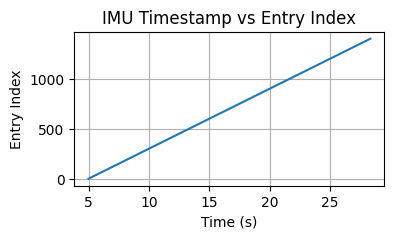

In [2]:
path = 'data/run1'
imu = pd.read_csv(f'{path}/imu.csv')

# plot timestamp vs entry index
imu['timestamp'] = (imu['timestamp'] - imu['timestamp'].iloc[0]) / 1e3 # convert nanoseconds to seconds
imu = imu[300:1700]
plt.figure(figsize=(4, 2))
plt.plot(imu['timestamp'], np.arange(len(imu)))
plt.title('IMU Timestamp vs Entry Index')
plt.xlabel('Time (s)')
plt.ylabel('Entry Index')
plt.grid()
plt.show()

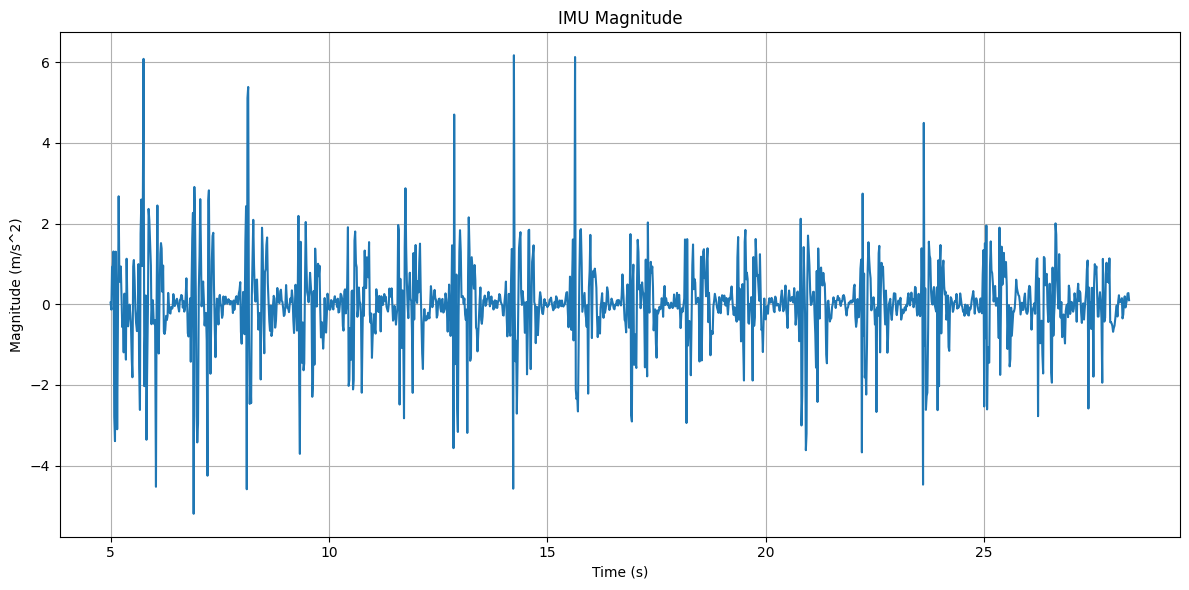

In [3]:
# aggregate imu
imu_mag = np.sqrt(imu['accel_x']**2 + imu['accel_y']**2 + imu['accel_z']**2)

# normalize imu magnitude
imu_mag = (imu_mag - np.mean(imu_mag)) / np.std(imu_mag)
plt.figure(figsize=(12, 6))
plt.plot(imu['timestamp'], imu_mag)
plt.title('IMU Magnitude')
plt.xlabel('Time (s)')
plt.ylabel('Magnitude (m/s^2)')
plt.grid()
plt.tight_layout()
plt.show()

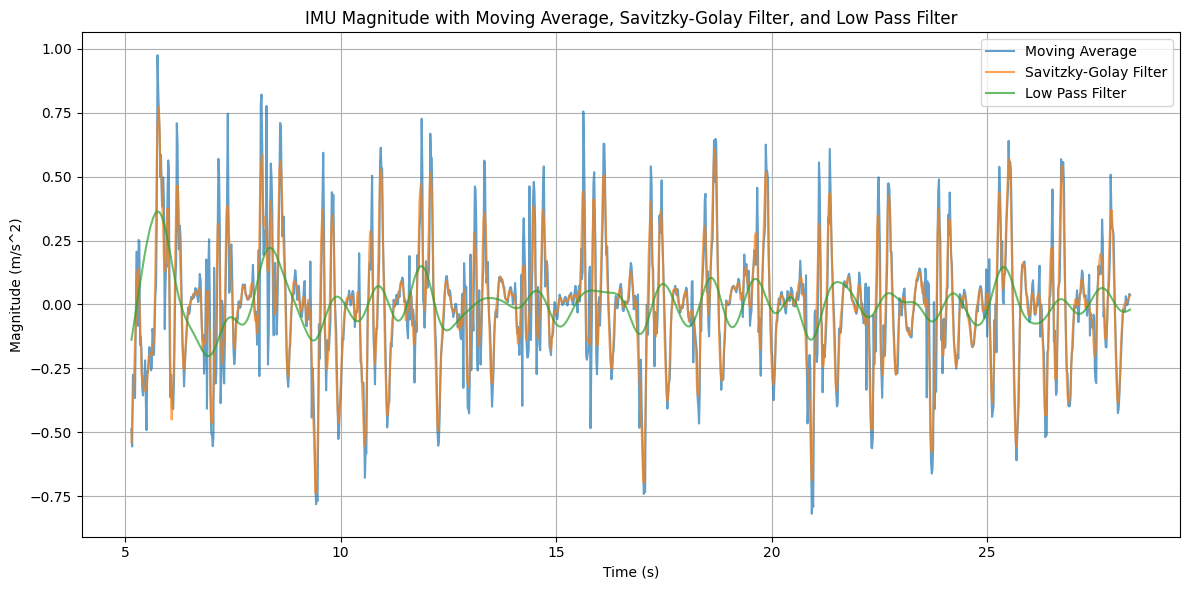

In [4]:
# apply moving average and savitzky-golay filter
def moving_average(signal, window_size):
    cumsum = np.cumsum(np.insert(signal, 0, 0)) 
    return (cumsum[window_size:] - cumsum[:-window_size]) / window_size

def savgol_filter_signal(signal, window_length, polyorder):
    return savgol_filter(signal, window_length, polyorder)

def band_pass_filter(signal, lowcut, highcut, fs, order=4):
    sos = butter(order, [lowcut, highcut], btype='band', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)


moving_window_size = 10
savgol_window_length = 10
imu_mag_ma = moving_average(imu_mag, window_size=moving_window_size)
imu_mag_sg = savgol_filter_signal(imu_mag_ma, window_length=savgol_window_length, polyorder=2)
imu_mag_low = band_pass_filter(imu_mag_sg, lowcut=0.5, highcut=2, fs=100)
imu_mag_hr = band_pass_filter(imu_mag_sg, lowcut=3.5, highcut=5.5, fs=100)

plt.figure(figsize=(12, 6))
plt.plot(imu['timestamp'][moving_window_size-1:], imu_mag_ma, label='Moving Average', alpha=0.7)
plt.plot(imu['timestamp'][moving_window_size-1:], imu_mag_sg, label='Savitzky-Golay Filter', alpha=0.7)
plt.plot(imu['timestamp'][moving_window_size-1:], imu_mag_low, label='Low Pass Filter', alpha=0.7)
plt.title('IMU Magnitude with Moving Average, Savitzky-Golay Filter, and Low Pass Filter')
plt.xlabel('Time (s)')
plt.ylabel('Magnitude (m/s^2)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

0.86 Hz = 69.55 BPM


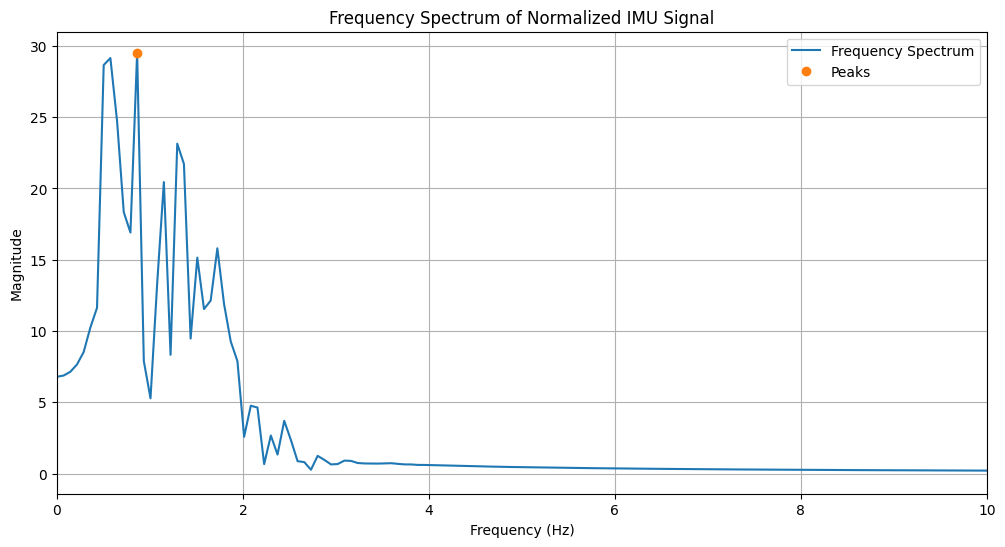

In [5]:
fft_vals = rfft(imu_mag_low)
fft_freq = rfftfreq(len(imu_mag_low), 1/100)
peaks = find_peaks(np.abs(fft_vals), height=20, distance=10)[0]

for peak in peaks:
    print(f"{fft_freq[peak]:.2f} Hz = {60/fft_freq[peak]:.2f} BPM")

plt.figure(figsize=(12, 6))
plt.plot(fft_freq, np.abs(fft_vals), label='Frequency Spectrum')
plt.plot(fft_freq[peaks], np.abs(fft_vals)[peaks], 'o', label='Peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Spectrum of Normalized IMU Signal')
plt.xlim(0, 10)
plt.legend()
plt.grid(True)
plt.show()

4.82 Hz = 12.46 BPM


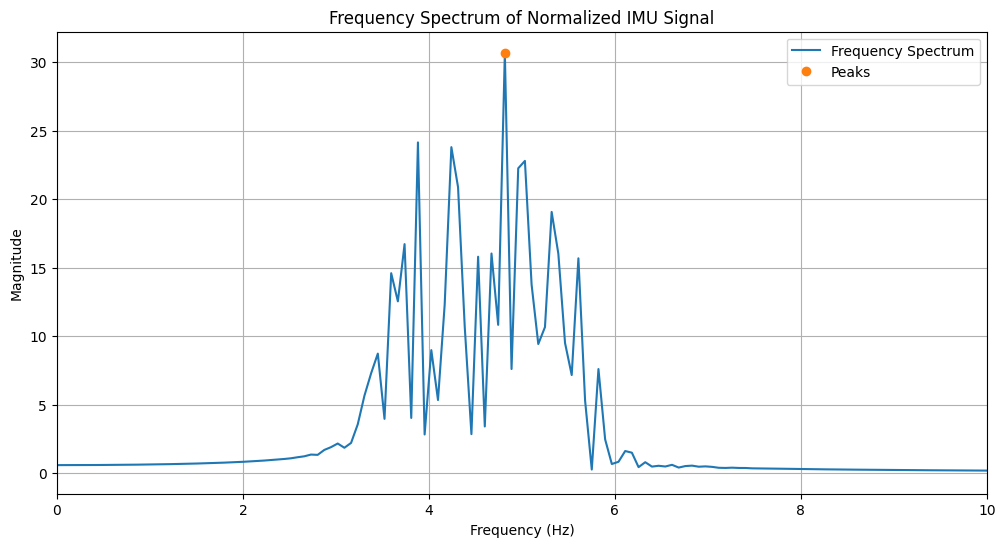

In [6]:
fft_vals = rfft(imu_mag_hr)
fft_freq = rfftfreq(len(imu_mag_hr), 1/100)
peaks = find_peaks(np.abs(fft_vals), height=25, distance=10)[0]

for peak in peaks:
    print(f"{fft_freq[peak]:.2f} Hz = {60/fft_freq[peak]:.2f} BPM")

plt.figure(figsize=(12, 6))
plt.plot(fft_freq, np.abs(fft_vals), label='Frequency Spectrum')
plt.plot(fft_freq[peaks], np.abs(fft_vals)[peaks], 'o', label='Peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Spectrum of Normalized IMU Signal')
plt.xlim(0, 10)
plt.legend()
plt.grid(True)
plt.show()

# Microphone

In [7]:
y, sr = librosa.load(f'{path}/audio.mp3', sr=None)

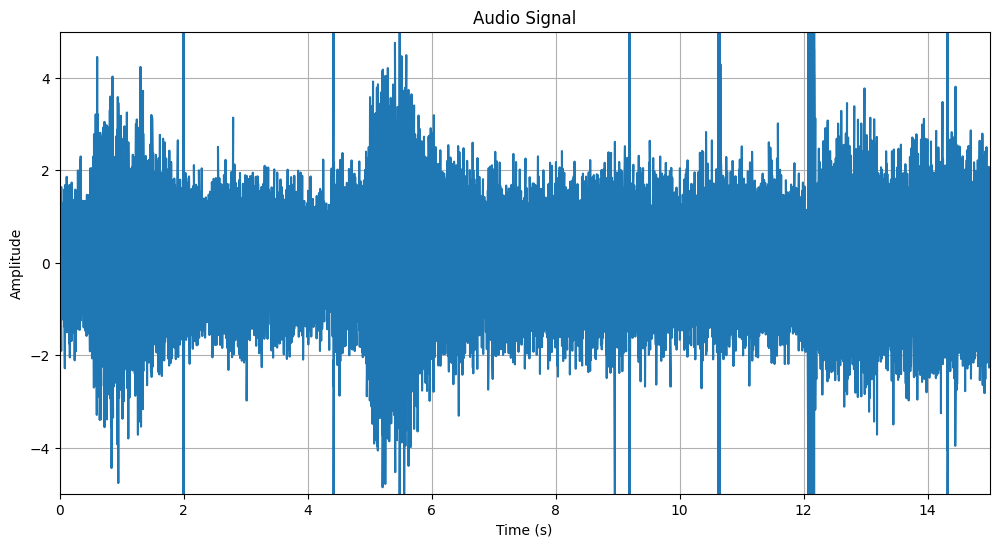

In [8]:
# normalize audio
y = (y - np.mean(y)) / np.std(y)
plt.rcParams['agg.path.chunksize'] = 10000
plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 1.0

# # only keep first 60 seconds
y = y[:int(15*sr)]

# plot audio
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(y)) / sr, y)
plt.title('Audio Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.xlim(0, len(y) / sr)
plt.ylim(-5, 5)
plt.grid()
plt.show()

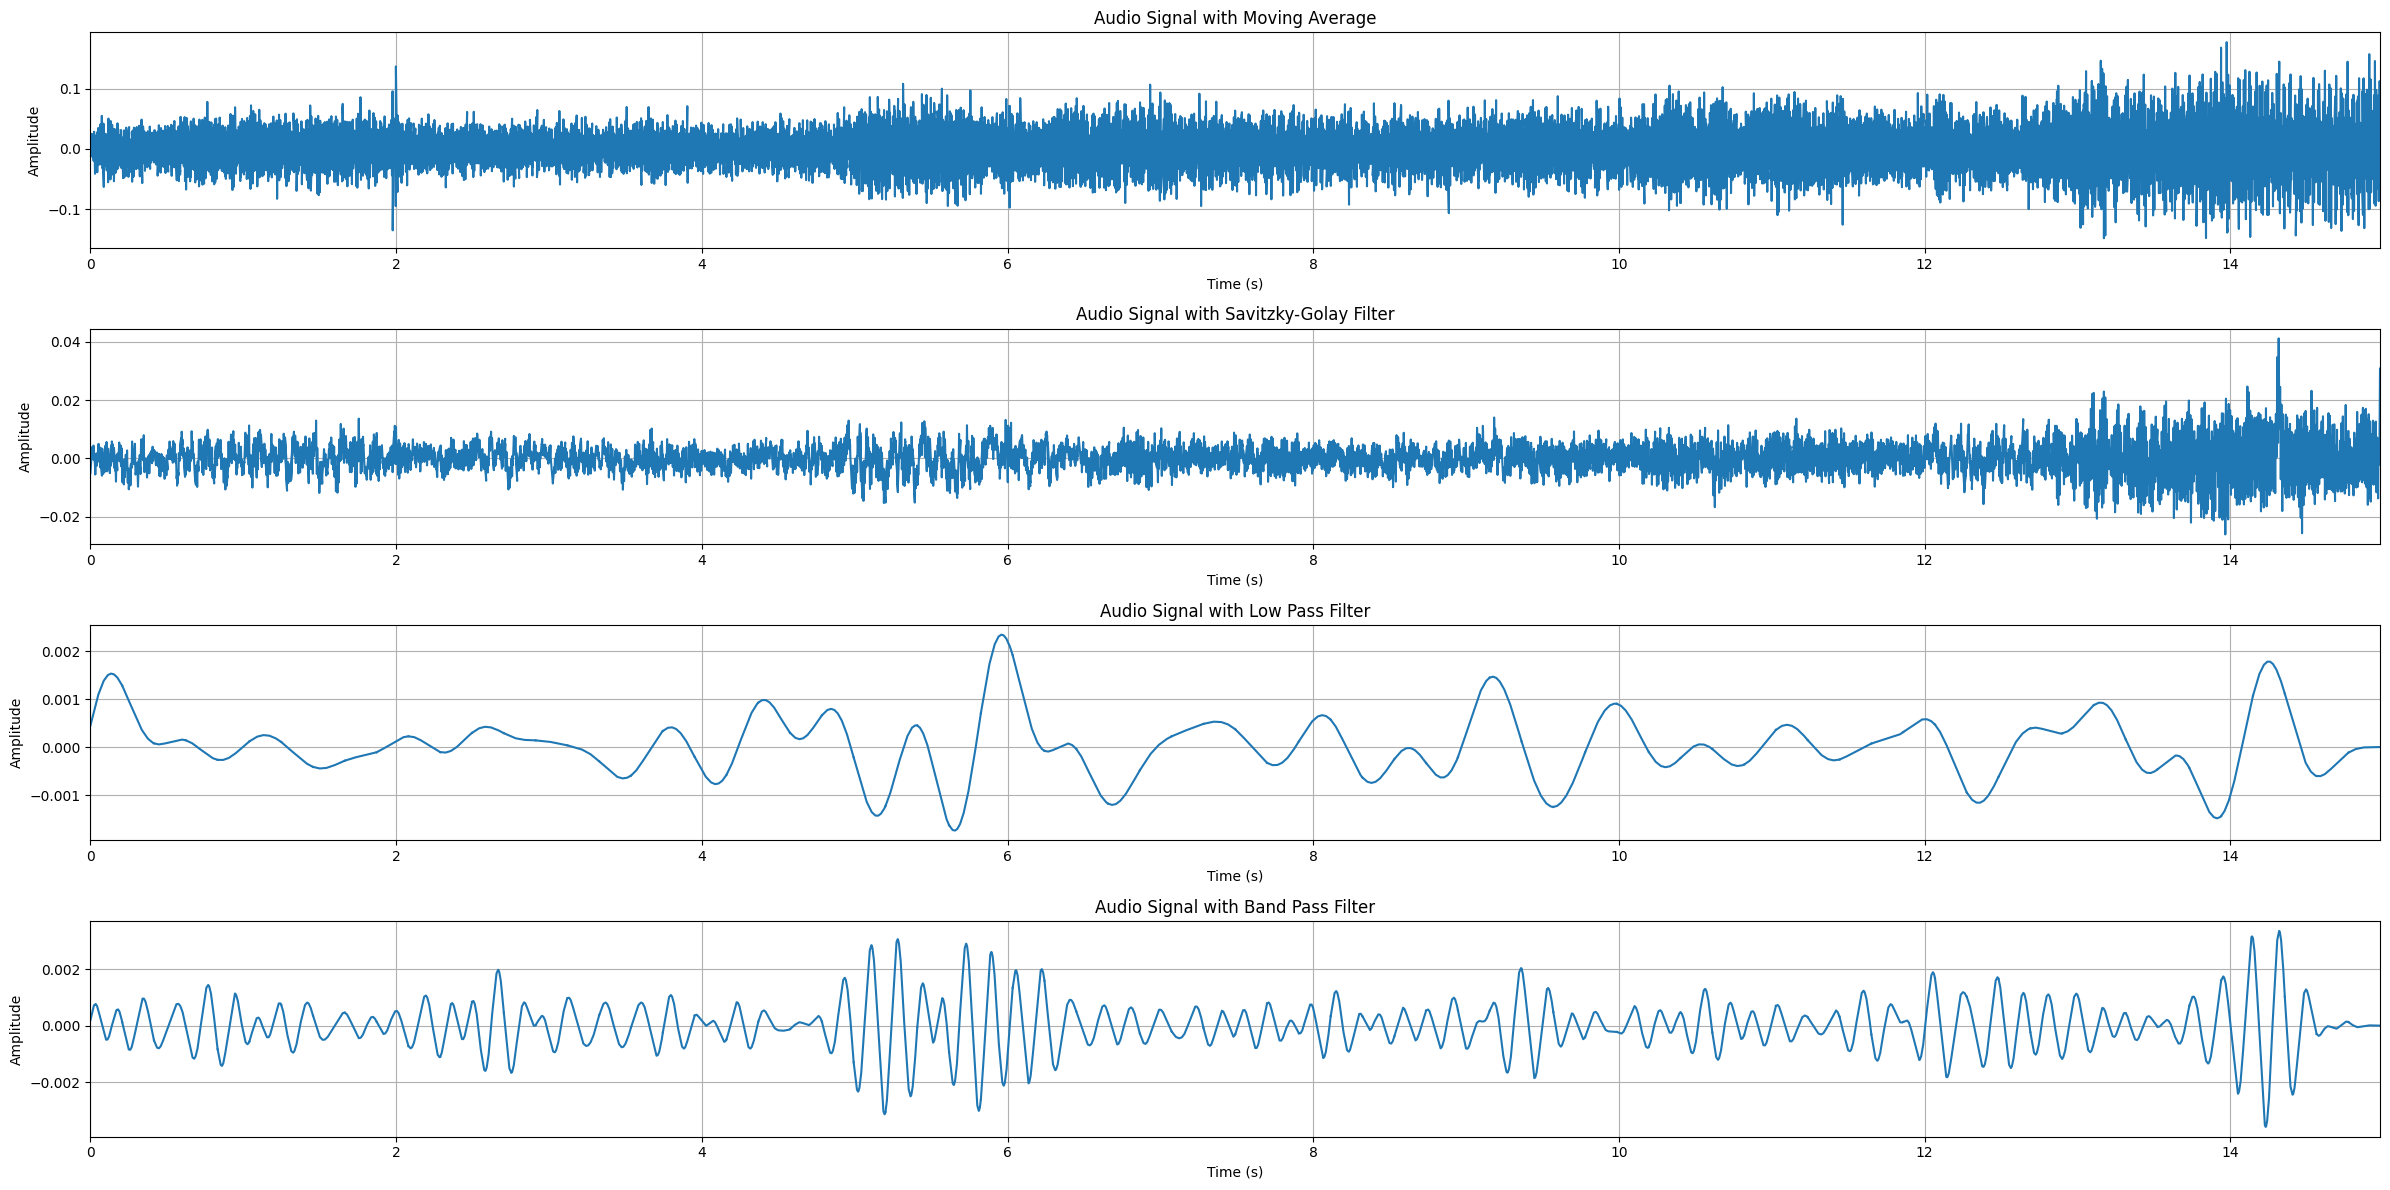

In [9]:
def band_pass_filter(signal, lowcut, highcut, fs, order=4):
    sos = butter(order, [lowcut, highcut], btype='band', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)

moving_window_size = 1000
savgol_window_length = 1000
audio_moving = moving_average(y, window_size=moving_window_size)
audio_sg = savgol_filter_signal(audio_moving, window_length=savgol_window_length, polyorder=3)
audio_low = band_pass_filter(audio_sg, lowcut=0.5, highcut=2, fs=sr)
audio_hr = band_pass_filter(audio_sg, lowcut=4, highcut=7, fs=sr)

# plot multiplot of audio
plt.figure(figsize=(24, 12))
plt.subplot(4, 1, 1)
plt.plot(np.arange(len(audio_moving)) / sr, audio_moving)
plt.title('Audio Signal with Moving Average')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.xlim(0, len(audio_moving) / sr)
plt.grid()
plt.subplot(4, 1, 2)
plt.plot(np.arange(len(audio_sg)) / sr, audio_sg)
plt.title('Audio Signal with Savitzky-Golay Filter')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.xlim(0, len(audio_sg) / sr)
plt.grid()
# breathing pass
plt.subplot(4, 1, 3)
plt.plot(np.arange(len(audio_low)) / sr, audio_low)
plt.title('Audio Signal with Low Pass Filter')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.xlim(0, len(audio_low) / sr)
plt.grid()
# HR pass
plt.subplot(4, 1, 4)
plt.plot(np.arange(len(audio_hr)) / sr, audio_hr)
plt.title('Audio Signal with Band Pass Filter')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.xlim(0, len(audio_hr) / sr)
plt.grid()
plt.tight_layout()
plt.show()

1.00 Hz = 59.92 BPM


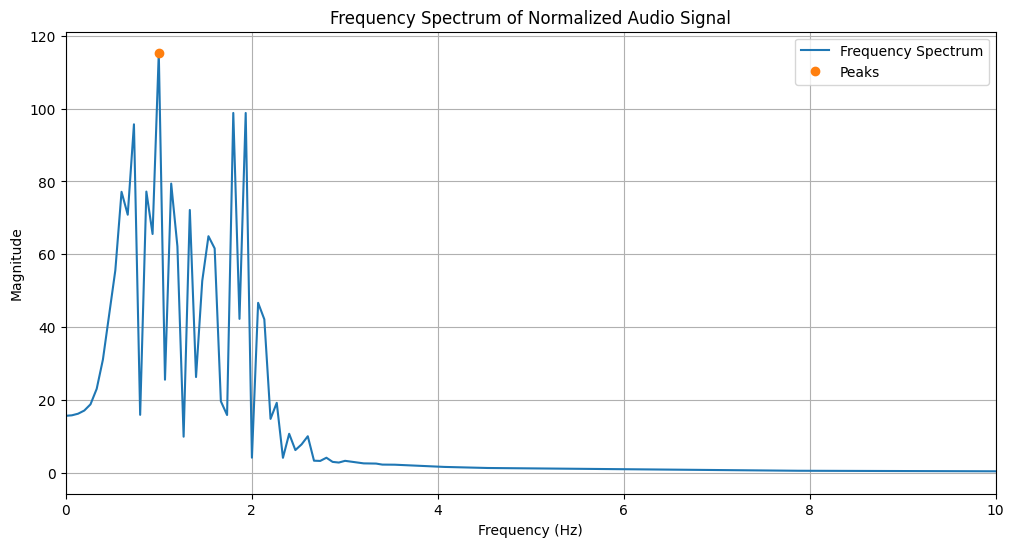

In [10]:
audio_fft_vals = rfft(audio_low)
audio_fft_freq = rfftfreq(len(audio_low), 1/sr)

peaks = find_peaks(np.abs(audio_fft_vals), height=100, distance=1)[0]

for peak in peaks:
    print(f"{audio_fft_freq[peak]:.2f} Hz = {60/audio_fft_freq[peak]:.2f} BPM")

plt.figure(figsize=(12, 6))
plt.plot(audio_fft_freq, np.abs(audio_fft_vals), label='Frequency Spectrum')
plt.plot(audio_fft_freq[peaks], np.abs(audio_fft_vals)[peaks], 'o', label='Peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Spectrum of Normalized Audio Signal')
plt.xlim(0, 10)
plt.legend()
plt.grid(True)
plt.show()

5.21 Hz = 11.52 BPM


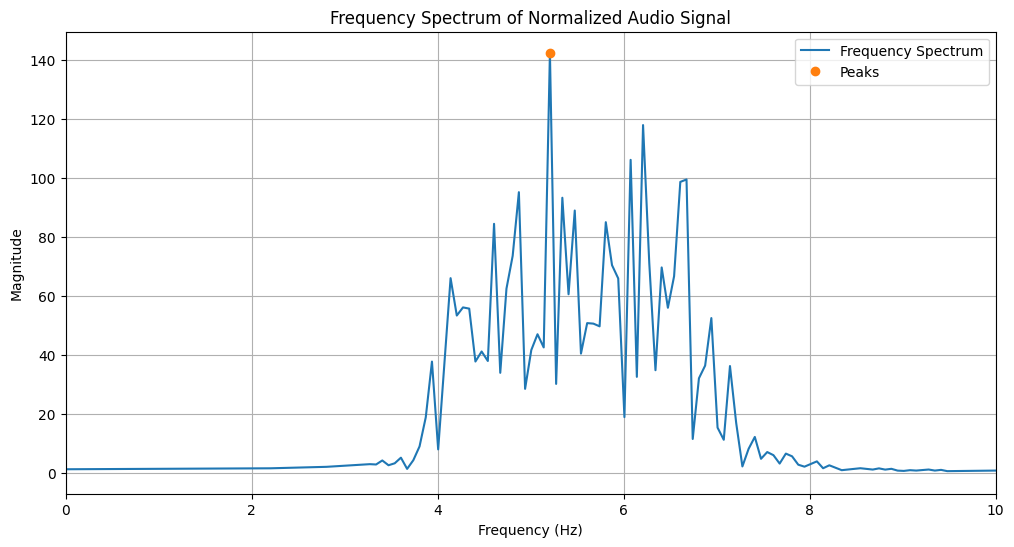

In [11]:
audio_fft_vals = rfft(audio_hr)
audio_fft_freq = rfftfreq(len(audio_hr), 1/sr)

peaks = find_peaks(np.abs(audio_fft_vals), height=120)[0]

for peak in peaks:
    print(f"{audio_fft_freq[peak]:.2f} Hz = {60/audio_fft_freq[peak]:.2f} BPM")

plt.figure(figsize=(12, 6))
plt.plot(audio_fft_freq, np.abs(audio_fft_vals), label='Frequency Spectrum')
plt.plot(audio_fft_freq[peaks], np.abs(audio_fft_vals)[peaks], 'o', label='Peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Spectrum of Normalized Audio Signal')
plt.xlim(0, 10)
plt.legend()
plt.grid(True)
plt.show()